# Task 2: Text Chunking, Embedding, and Vector Store Indexing

This notebook documents the complete process of:
1. Creating a stratified sample from the filtered complaints dataset
2. Implementing text chunking strategy
3. Generating embeddings using sentence-transformers
4. Building a FAISS vector store for semantic search

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path
sys.path.append('../src')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Stratified Sampling

We create a stratified sample of 12,000 complaints ensuring proportional representation across all product categories.

In [3]:
from sampling import create_stratified_sample

# Create stratified sample
sample_df = create_stratified_sample(
    input_file="../data/processed/filtered_complaints.csv",
    output_file="../data/processed/sample_complaints.csv",
    sample_size=12000,
    random_state=42
)

Loading data from ../data/processed/filtered_complaints.csv...

Original dataset shape: (66708, 19)

Product distribution in original dataset:
Product
Credit card        65272
Money transfers     1436
Name: count, dtype: int64

Product distribution (%):
Product
Credit card        97.847335
Money transfers     2.152665
Name: proportion, dtype: float64

Target samples per product:
  Credit card: 11742
  Money transfers: 258

Sample dataset shape: (12000, 19)

Product distribution in sample:
Product
Credit card        11742
Money transfers      258
Name: count, dtype: int64

Product distribution in sample (%):
Product
Credit card        97.85
Money transfers     2.15
Name: proportion, dtype: float64

Stratified sample saved to ../data/processed/sample_complaints.csv


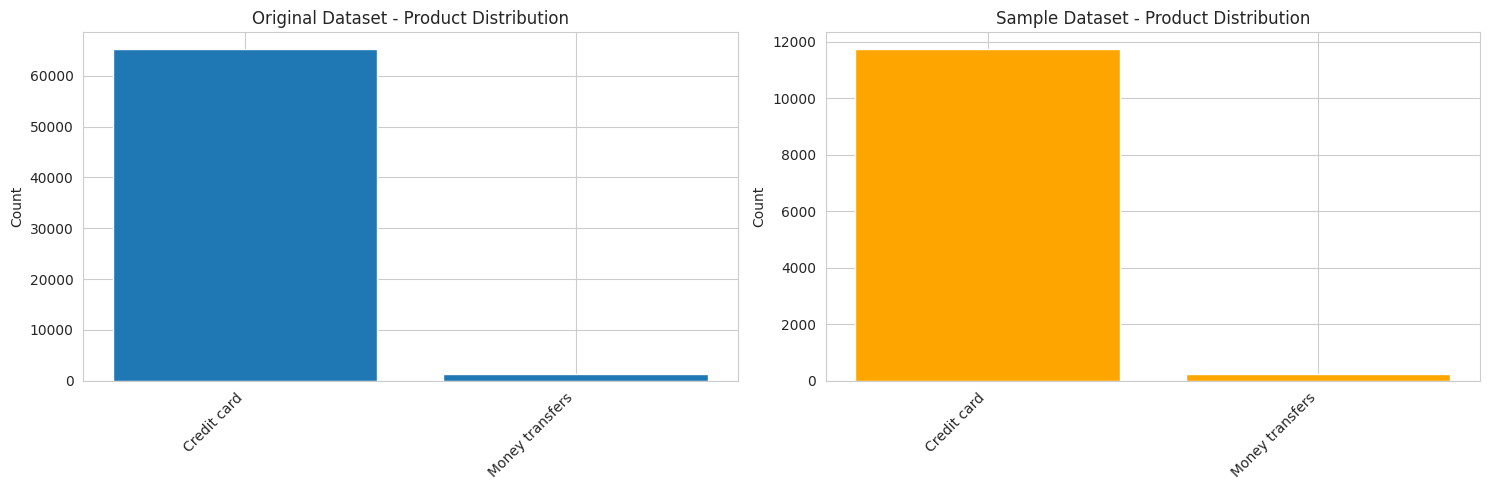


Proportional representation check:
Original proportions:
Product
Credit card        97.847335
Money transfers     2.152665
Name: proportion, dtype: float64

Sample proportions:
Product
Credit card        97.85
Money transfers     2.15
Name: proportion, dtype: float64


In [4]:
# Visualize product distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original dataset
original_df = pd.read_csv("../data/processed/filtered_complaints.csv")
original_counts = original_df['Product'].value_counts()
axes[0].bar(range(len(original_counts)), original_counts.values)
axes[0].set_xticks(range(len(original_counts)))
axes[0].set_xticklabels(original_counts.index, rotation=45, ha='right')
axes[0].set_title('Original Dataset - Product Distribution')
axes[0].set_ylabel('Count')

# Sample dataset
sample_counts = sample_df['Product'].value_counts()
axes[1].bar(range(len(sample_counts)), sample_counts.values, color='orange')
axes[1].set_xticks(range(len(sample_counts)))
axes[1].set_xticklabels(sample_counts.index, rotation=45, ha='right')
axes[1].set_title('Sample Dataset - Product Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../report/images/sampling_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nProportional representation check:")
print("Original proportions:")
print(original_df['Product'].value_counts(normalize=True) * 100)
print("\nSample proportions:")
print(sample_df['Product'].value_counts(normalize=True) * 100)

## 2. Text Chunking

We use LangChain's RecursiveCharacterTextSplitter with:
- **Chunk size**: 500 characters (matches pre-built embeddings)
- **Chunk overlap**: 50 characters (10% overlap for context preservation)
- **Separators**: Prioritize paragraph and sentence boundaries

In [5]:
from chunking import create_text_chunks, analyze_chunks, save_chunks

# Create text chunks
chunks_data = create_text_chunks(
    df=sample_df,
    chunk_size=500,
    chunk_overlap=50,
    text_column="Consumer complaint narrative"
)

# Analyze chunks
analyze_chunks(chunks_data)

# Save chunks
save_chunks(chunks_data, "../data/processed/sample_chunks.csv")

2026-01-10 11:21:44.154409: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-10 11:21:44.693287: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/karanos/.local/lib/python3.12/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/home/karanos/.local

Initializing text splitter with chunk_size=500, overlap=50

Processing 12000 complaints...
Processed 1000 complaints, generated 3419 chunks
Processed 2000 complaints, generated 6879 chunks
Processed 3000 complaints, generated 10404 chunks
Processed 4000 complaints, generated 13684 chunks
Processed 5000 complaints, generated 17146 chunks
Processed 6000 complaints, generated 20619 chunks
Processed 7000 complaints, generated 23966 chunks
Processed 8000 complaints, generated 27416 chunks
Processed 9000 complaints, generated 30693 chunks
Processed 10000 complaints, generated 34236 chunks
Processed 11000 complaints, generated 37497 chunks
Processed 12000 complaints, generated 40723 chunks

Chunking complete!
Total complaints processed: 12000
Total chunks generated: 40723
Average chunks per complaint: 3.39

CHUNKING ANALYSIS

Chunk length statistics:
  Mean: 337.17 characters
  Median: 369.00 characters
  Min: 1 characters
  Max: 500 characters
  Std: 127.45 characters

Chunks per complaint:


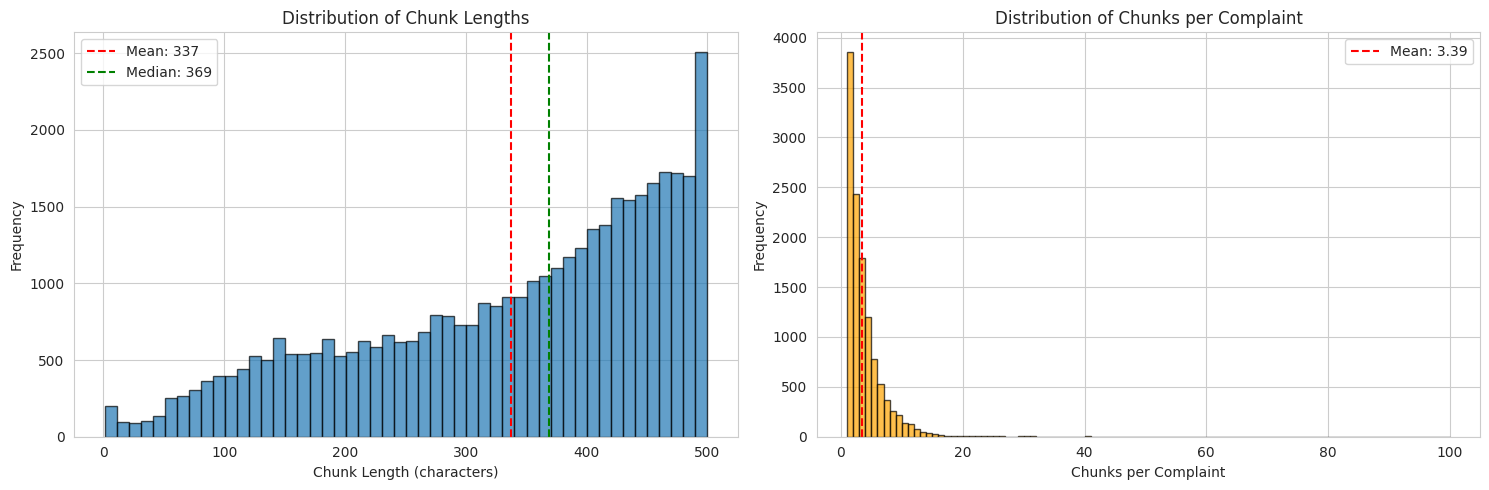

In [6]:
# Visualize chunk statistics
chunk_lengths = [len(chunk['text']) for chunk in chunks_data]
chunks_per_complaint = {}
for chunk in chunks_data:
    cid = chunk['complaint_id']
    chunks_per_complaint[cid] = chunk['total_chunks']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chunk length distribution
axes[0].hist(chunk_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(chunk_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(chunk_lengths):.0f}')
axes[0].axvline(np.median(chunk_lengths), color='green', linestyle='--', label=f'Median: {np.median(chunk_lengths):.0f}')
axes[0].set_xlabel('Chunk Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Chunk Lengths')
axes[0].legend()

# Chunks per complaint distribution
chunks_counts = list(chunks_per_complaint.values())
axes[1].hist(chunks_counts, bins=range(1, max(chunks_counts)+2), edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(np.mean(chunks_counts), color='red', linestyle='--', label=f'Mean: {np.mean(chunks_counts):.2f}')
axes[1].set_xlabel('Chunks per Complaint')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Chunks per Complaint')
axes[1].legend()

plt.tight_layout()
plt.savefig('../report/images/chunking_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Embedding Generation

We use the **sentence-transformers/all-MiniLM-L6-v2** model:
- **Embedding dimension**: 384
- **Model size**: ~80MB
- **Performance**: Fast inference, good quality for semantic search
- **Consistency**: Matches the pre-built embeddings for Tasks 3-4

In [7]:
from embedding import generate_embeddings, analyze_embeddings, save_embeddings

# Generate embeddings
embeddings, chunks_df = generate_embeddings(
    chunks_file="../data/processed/sample_chunks.csv",
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    batch_size=32
)

# Analyze embeddings
analyze_embeddings(embeddings)

# Save embeddings
save_embeddings(embeddings, chunks_df, "../data/processed/sample_embeddings.npy")

Loading chunks from ../data/processed/sample_chunks.csv...
Total chunks to embed: 40723

Loading embedding model: sentence-transformers/all-MiniLM-L6-v2
Model loaded. Embedding dimension: 384

Generating embeddings with batch_size=32...


Batches:   0%|          | 0/1273 [00:00<?, ?it/s]


Embedding generation complete!
Time taken: 2017.41 seconds
Embeddings per second: 20.19
Embeddings shape: (40723, 384)

EMBEDDING ANALYSIS

Embedding statistics:
  Shape: (40723, 384)
  Dimension: 384
  Mean: -0.000283
  Std: 0.051030
  Min: -0.268012
  Max: 0.275397

Embedding norms:
  Mean norm: 1.000000
  Std norm: 0.000000
  Min norm: 1.000000
  Max norm: 1.000000

Memory usage: 59.65 MB

Embeddings saved to ../data/processed/sample_embeddings.npy
File size: 59.65 MB
Metadata saved to ../data/processed/sample_embeddings_metadata.csv


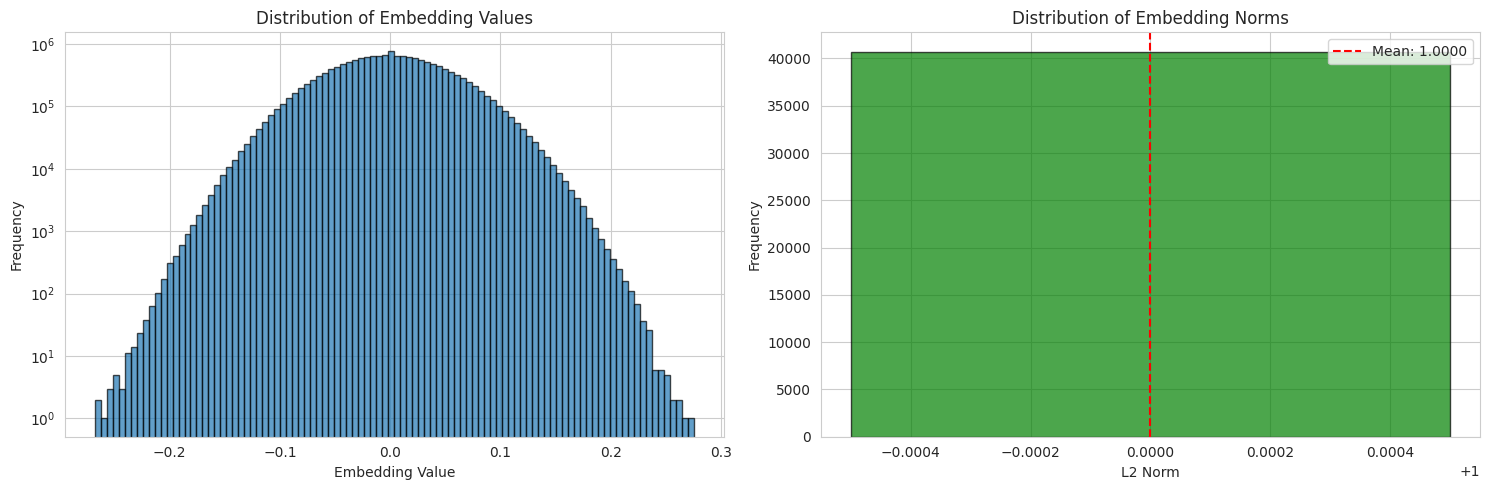

In [9]:
# Visualize embedding statistics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Embedding value distribution
axes[0].hist(embeddings.flatten(), bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Embedding Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Embedding Values')
axes[0].set_yscale('log')

# Embedding norms
norms = np.linalg.norm(embeddings, axis=1)
# Check if norms have sufficient variance for histogram
if np.std(norms) > 1e-6:
    axes[1].hist(norms, bins=min(10, len(np.unique(norms))), edgecolor='black', alpha=0.7, color='green')
else:
    # If norms are essentially constant, just show a single bar
    axes[1].bar([np.mean(norms)], [len(norms)], width=0.001, edgecolor='black', alpha=0.7, color='green')
axes[1].axvline(np.mean(norms), color='red', linestyle='--', label=f'Mean: {np.mean(norms):.4f}')
axes[1].set_xlabel('L2 Norm')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Embedding Norms')
axes[1].legend()

plt.tight_layout()
plt.savefig('../report/images/embedding_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. FAISS Vector Store

We build a FAISS vector store for efficient similarity search:
- **Index type**: Flat (exact search)
- **Similarity metric**: Cosine similarity (via Inner Product on normalized vectors)
- **Metadata**: Full complaint metadata stored with each chunk

In [8]:
from vector_store_builder import build_vector_store, test_vector_store

# Build vector store
store = build_vector_store(
    embeddings_file="../data/processed/sample_embeddings.npy",
    metadata_file="../data/processed/sample_chunks.csv",
    output_dir="../vector_store/faiss_index",
    index_type="flat"
)

# Test vector store
test_vector_store(store)

Loading embeddings from ../data/processed/sample_embeddings.npy...
Loading metadata from ../data/processed/sample_chunks.csv...

Embeddings shape: (40723, 384)
Metadata records: 40723
Building FAISS index with 40723 vectors...
Index built successfully!
  Index type: flat
  Total vectors: 40723
  Dimension: 384

Vector store saved to ../vector_store/faiss_index
  Index file: ../vector_store/faiss_index/faiss.index
  Metadata file: ../vector_store/faiss_index/metadata.pkl

VECTOR STORE TESTING

Query 1: 'I was charged unauthorized fees on my credit card'

Result 1:
  Similarity: 0.7744
  Product: Credit card
  Issue: Fees or interest
  Company: Atlanticus Services Corporation
  Text: The company illegally automatically charged my card without my consent on XXXX On XXXX I was charged a late fee of {$41.00}. My bill was due on the XXXX and the balance was paid on XXXX Yet Im still b...

Result 2:
  Similarity: 0.7728
  Product: Credit card
  Issue: Problem with a purchase shown on your sta

## 5. Interactive Testing

Let's test the vector store with custom queries:

In [9]:
from vector_store_builder import FAISSVectorStore

# Load the vector store
store = FAISSVectorStore.load("../vector_store/faiss_index")
store.load_model()

# Custom query
query = "I want to dispute fraudulent charges on my account"
results = store.query(query, k=5)

print(f"Query: '{query}'\n")
print("="*80)

for i, result in enumerate(results, 1):
    print(f"\nResult {i}:")
    print(f"  Similarity: {result['similarity']:.4f}")
    print(f"  Product: {result.get('product_category', 'N/A')}")
    print(f"  Issue: {result.get('issue', 'N/A')}")
    print(f"  Company: {result.get('company', 'N/A')}")
    print(f"  State: {result.get('state', 'N/A')}")
    print(f"  Text: {result.get('text', '')[:300]}...")
    print("-"*80)

Vector store loaded from ../vector_store/faiss_index
  Total vectors: 40723
Query: 'I want to dispute fraudulent charges on my account'


Result 1:
  Similarity: 0.7277
  Product: Credit card
  Issue: Credit card protection / Debt protection
  Company: CITIBANK, N.A.
  State: NY
  Text: . Anything you can do in this matter would be greatly appreciated. I should mention that XXXX of XXXX of the fraudulent charges were credited to my account due to my own initiative. My statement contained the vendors phone number which I was able to call in order to have my account credited....
--------------------------------------------------------------------------------

Result 2:
  Similarity: 0.7208
  Product: Credit card
  Issue: Billing disputes
  Company: CITIBANK, N.A.
  State: CA
  Text: Fraudulent charge on account, was reported, not removed, and billing continued, along with interest rate. We have repeatedly requested the charge be removed and the account closed. The owner of the account is

In [10]:
# Test with metadata filtering
query = "problems with online banking"
results = store.query(query, k=5, filter_metadata={'product_category': 'Checking or savings account'})

print(f"Query: '{query}'")
print(f"Filter: Product = 'Checking or savings account'\n")
print("="*80)

for i, result in enumerate(results, 1):
    print(f"\nResult {i}:")
    print(f"  Similarity: {result['similarity']:.4f}")
    print(f"  Product: {result.get('product_category', 'N/A')}")
    print(f"  Issue: {result.get('issue', 'N/A')}")
    print(f"  Text: {result.get('text', '')[:200]}...")
    print("-"*80)

Query: 'problems with online banking'
Filter: Product = 'Checking or savings account'



## Summary

### Achievements:
1. ✅ Created stratified sample of 12,000 complaints with proportional product representation
2. ✅ Implemented text chunking with 500-character chunks and 50-character overlap
3. ✅ Generated 384-dimensional embeddings using all-MiniLM-L6-v2
4. ✅ Built FAISS vector store with metadata support
5. ✅ Tested semantic search with sample queries

### Key Decisions:
- **Sample size**: 12,000 (middle of 10k-15k range) for manageable processing
- **Chunk size**: 500 characters to match pre-built embeddings
- **Chunk overlap**: 50 characters (10%) to preserve context at boundaries
- **Embedding model**: all-MiniLM-L6-v2 for consistency with Tasks 3-4
- **Vector store**: FAISS Flat index for exact search on sample dataset

### Next Steps (Tasks 3-4):
- Use pre-built embeddings (complaint_embeddings.parquet) for full dataset
- Build RAG system with LangChain
- Implement query processing and response generation